Cek file sudah masuk

In [78]:
import os

os.listdir('/content')

['.config',
 'train.csv',
 'submission_titanic.csv',
 '.ipynb_checkpoints',
 'test.csv',
 'gender_submission.csv',
 'sample_data']

In [79]:
# ===============================
# 1. Import Library
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Load data dengan pandas

In [80]:
import pandas as pd

train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')
submission_df = pd.read_csv('/content/gender_submission.csv')

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 1 — Cek ukuran dataset

In [81]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Submission shape:", submission_df.shape)

Train shape: (891, 12)
Test shape: (418, 11)
Submission shape: (418, 2)


# Step 2 — Lihat 5 data pertama

In [82]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [83]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Step 3 — Cek informasi kolom

In [84]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Step 4 — Cek missing value

In [85]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Step 5 — Cek statistik numerik

In [86]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Step 6 — Cek distribusi target

In [87]:
train_df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [88]:
train_df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


# Step 7 — Mulai visualisasi EDA

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

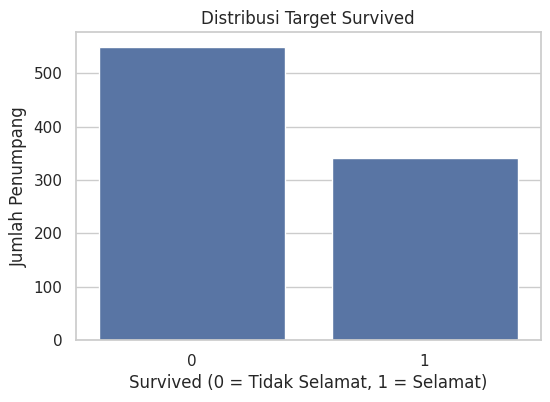

In [90]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='Survived')
plt.title('Distribusi Target Survived')
plt.xlabel('Survived (0 = Tidak Selamat, 1 = Selamat)')
plt.ylabel('Jumlah Penumpang')
plt.show()

# Step 8 — Grafik survival berdasarkan jenis kelamin

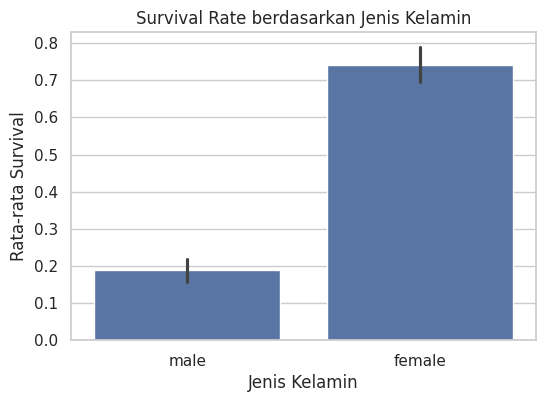

In [91]:
plt.figure(figsize=(6,4))
sns.barplot(data=train_df, x='Sex', y='Survived')
plt.title('Survival Rate berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Rata-rata Survival')
plt.show()

# Step 9 — Grafik survival berdasarkan kelas tiket

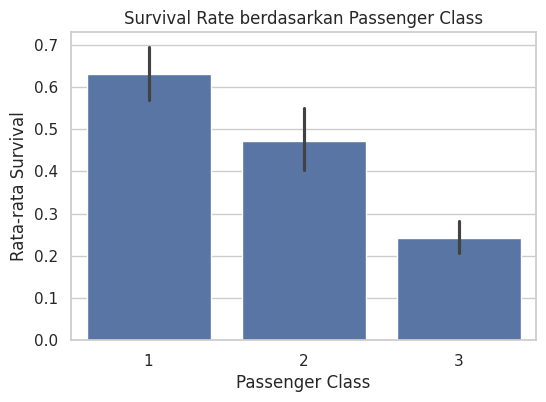

In [92]:
plt.figure(figsize=(6,4))
sns.barplot(data=train_df, x='Pclass', y='Survived')
plt.title('Survival Rate berdasarkan Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Rata-rata Survival')
plt.show()

# Step 11 — Gabungkan train dan test sementara

In [93]:
# Simpan target dulu
y = train_df['Survived']

# Gabungkan train dan test untuk preprocessing konsisten
train_features = train_df.drop(columns=['Survived'])
combined = pd.concat([train_features, test_df], axis=0, ignore_index=True)

combined.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 12 — Ekstraksi Title dari Name

In [94]:
combined['Title'] = combined['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

combined['Title'].value_counts()

,count
Title,
Mr,757
Miss,260
Mrs,197
Master,61
Rev,8
Dr,8
Col,4
Major,2
Mlle,2


Lalu sederhanakan title yang jarang muncul

In [95]:
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Mlle': 'Miss',
    'Countess': 'Rare',
    'Ms': 'Miss',
    'Lady': 'Rare',
    'Jonkheer': 'Rare',
    'Don': 'Rare',
    'Dona': 'Rare',
    'Mme': 'Mrs',
    'Capt': 'Rare',
    'Sir': 'Rare'
}

combined['Title'] = combined['Title'].map(title_mapping)
combined['Title'] = combined['Title'].fillna('Rare')

combined['Title'].value_counts()

,count
Title,
Mr,757
Miss,264
Mrs,198
Master,61
Rare,29


# Step 13 — FamilySize dan IsAlone

In [96]:
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1

combined['IsAlone'] = 0
combined.loc[combined['FamilySize'] == 1, 'IsAlone'] = 1

combined[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


# Step 14 — HasCabin

In [97]:
combined['HasCabin'] = combined['Cabin'].notnull().astype(int)

combined[['Cabin', 'HasCabin']].head()

,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0


# Step 15 - Imputasi Missing Values

In [98]:
combined.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,1014


Isi Age berdasarkan median per Title dan Pclass:

In [99]:
combined['Age'] = combined.groupby(['Title', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

Kalau masih ada yang kosong, isi dengan median global:

In [100]:
combined['Age'] = combined['Age'].fillna(combined['Age'].median())

Isi Embarked dengan modus:

In [101]:
combined['Embarked'] = combined['Embarked'].fillna(combined['Embarked'].mode()[0])

Isi Fare dengan median:

In [102]:
combined['Fare'] = combined['Fare'].fillna(combined['Fare'].median())

Cek lagi:

In [103]:
combined.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,1014


# Step 16 — AgeBin dan FareBin

In [104]:
combined['AgeBin'] = pd.cut(
    combined['Age'],
    bins=[0, 12, 19, 59, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

Buat kategori harga tiket:

In [105]:
combined['FareBin'] = pd.qcut(
    combined['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'VeryHigh']
)

Cek hasilnya:

In [106]:
combined[['Age', 'AgeBin', 'Fare', 'FareBin']].head()

,Age,AgeBin,Fare,FareBin
0,22.0,Adult,7.2500,Low
1,38.0,Adult,71.2833,VeryHigh
2,26.0,Adult,7.9250,Medium
3,35.0,Adult,53.1000,VeryHigh
4,35.0,Adult,8.0500,Medium


# Step 17 — Drop kolom yang tidak dipakai

In [107]:
combined_processed = combined.drop(columns=[
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin'
])

combined_processed.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin,AgeBin,FareBin
0,3,male,22.0,1,0,7.2500,S,Mr,2,0,0,Adult,Low
1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,1,Adult,VeryHigh
2,3,female,26.0,0,0,7.9250,S,Miss,1,1,0,Adult,Medium
3,1,female,35.0,1,0,53.1000,S,Mrs,2,0,1,Adult,VeryHigh
4,3,male,35.0,0,0,8.0500,S,Mr,1,1,0,Adult,Medium


# Step 18 — One-Hot Encoding

In [108]:
combined_encoded = pd.get_dummies(
    combined_processed,
    columns=['Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin'],
    drop_first=True
)

combined_encoded.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,Sex_male,Embarked_Q,...,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeBin_Teen,AgeBin_Adult,AgeBin_Senior,FareBin_Medium,FareBin_High,FareBin_VeryHigh
0,3,22.0,1,0,7.2500,2,0,0,True,False,...,False,True,False,False,False,True,False,False,False,False
1,1,38.0,1,0,71.2833,2,0,1,False,False,...,False,False,True,False,False,True,False,False,False,True
2,3,26.0,0,0,7.9250,1,1,0,False,False,...,True,False,False,False,False,True,False,True,False,False
3,1,35.0,1,0,53.1000,2,0,1,False,False,...,False,False,True,False,False,True,False,False,False,True
4,3,35.0,0,0,8.0500,1,1,0,True,False,...,False,True,False,False,False,True,False,True,False,False


# Step 19 — Pisahkan kembali train dan test

In [109]:
X = combined_encoded.iloc[:len(train_df), :].copy()
X_test_final = combined_encoded.iloc[len(train_df):, :].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test_final shape:", X_test_final.shape)

X shape: (891, 21)
y shape: (891,)
X_test_final shape: (418, 21)


# Step 20 — Train-validation split

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (712, 21)
X_val: (179, 21)
y_train: (712,)
y_val: (179,)


# Step 21 — Scaling fitur numerik

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

# Step 22 — Import library evaluasi

In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

# Step 23 — Buat fungsi evaluasi model

In [113]:
def evaluate_model(model_name, y_true, y_pred, training_time=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Model: {model_name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    if training_time is not None:
        print(f"Training Time: {training_time:.4f} seconds")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Training Time": training_time
    }

# Step 24 — Model 1: Logistic Regression

In [114]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

start_time = time.time()
logreg.fit(X_train_scaled, y_train)
logreg_time = time.time() - start_time

y_pred_logreg = logreg.predict(X_val_scaled)

result_logreg = evaluate_model(
    "Logistic Regression",
    y_val,
    y_pred_logreg,
    logreg_time
)

Model: Logistic Regression
Accuracy : 0.8436
Precision: 0.7971
Recall   : 0.7971
F1-score : 0.7971
Training Time: 0.0250 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       110
           1       0.80      0.80      0.80        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



Step 25 — Confusion Matrix Logistic Regression

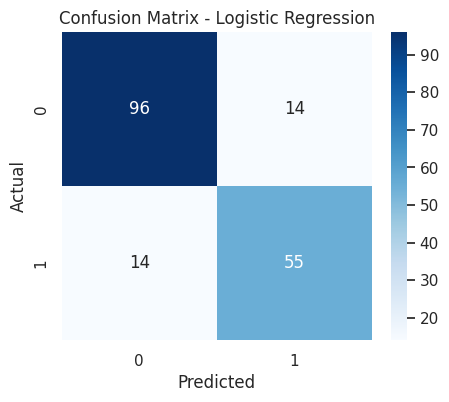

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_logreg = confusion_matrix(y_val, y_pred_logreg)

plt.figure(figsize=(5,4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 26 — Model 2: Random Forest

In [116]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

start_time = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start_time

y_pred_rf = rf.predict(X_val)

result_rf = evaluate_model(
    "Random Forest",
    y_val,
    y_pred_rf,
    rf_time
)

Model: Random Forest
Accuracy : 0.7989
Precision: 0.7200
Recall   : 0.7826
F1-score : 0.7500
Training Time: 0.4231 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       110
           1       0.72      0.78      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.80      0.80      0.80       179



Step 27 — Confusion Matrix Random Forest

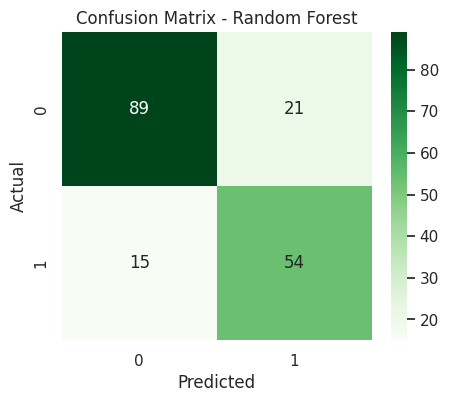

In [117]:
cm_rf = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 28 — Bandingkan hasil classical ML

In [118]:
results = []

results.append(result_logreg)
results.append(result_rf)

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Logistic Regression,0.843575,0.797101,0.797101,0.797101,0.024964
1,Random Forest,0.798883,0.720000,0.782609,0.750000,0.423111


In [119]:
results_df.sort_values(by='F1-score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Logistic Regression,0.843575,0.797101,0.797101,0.797101,0.024964
1,Random Forest,0.798883,0.720000,0.782609,0.750000,0.423111


# Step 29 — Feature Importance Random Forest

In [120]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
12,Title_Mr,0.228774
8,Sex_male,0.194207
4,Fare,0.104367
0,Pclass,0.063425
1,Age,0.060174
7,HasCabin,0.057349
11,Title_Miss,0.055459
5,FamilySize,0.053146
13,Title_Mrs,0.047777
2,SibSp,0.024805


Visualisasinya:

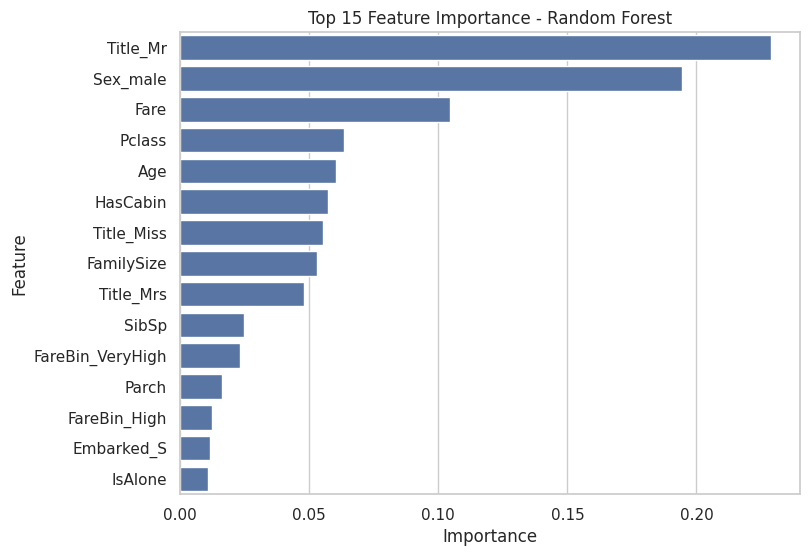

In [121]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Deep Learning untuk Titanic pakai MLP
# Step 31 — Import TensorFlow / Keras

In [122]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)

Cek versi TensorFlow:

In [123]:
print(tf.__version__)

2.19.0


# Step 32 — Buat model MLP

In [124]:
input_dim = X_train_scaled.shape[1]

mlp = Sequential([
    Dense(
        64,
        activation='relu',
        input_shape=(input_dim,),
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.3),

    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 33 — Compile model

In [125]:
mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 34 — Tampilkan summary model

In [126]:
mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 192 (768.00 B)

# Step 35 — Early Stopping

In [127]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Step 36 — Train MLP

In [128]:
start_time = time.time()

history = mlp.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

mlp_time = time.time() - start_time

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6067 - loss: 0.7683 - val_accuracy: 0.6816 - val_loss: 0.6999
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7022 - loss: 0.6230 - val_accuracy: 0.7318 - val_loss: 0.6426
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7374 - loss: 0.5935 - val_accuracy: 0.7430 - val_loss: 0.6109
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7570 - loss: 0.5648 - val_accuracy: 0.7933 - val_loss: 0.5910
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7669 - loss: 0.5643 - val_accuracy: 0.7821 - val_loss: 0.5782
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8034 - loss: 0.5176 - val_accuracy: 0.7989 - val_loss: 0.5704
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7992 - loss: 0.5193 - val_accuracy: 0.8101 - val_loss: 0.5590
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7992 - loss: 0.5018 - val_accuracy: 0.

# Step 37 — Plot training history

Accuracy curve

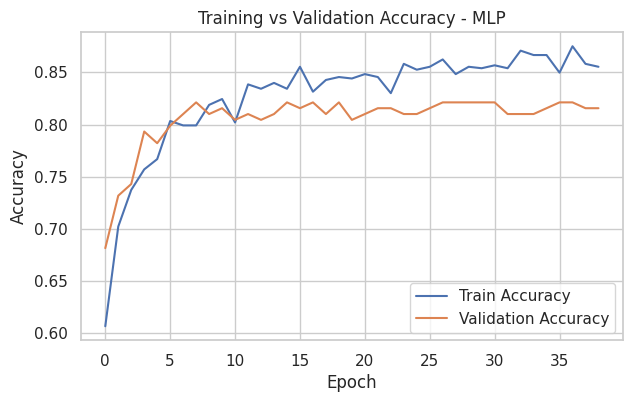

In [129]:
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy - MLP')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Loss curve

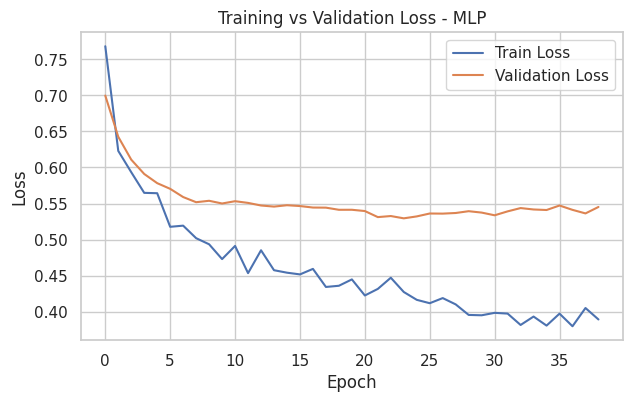

In [130]:
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss - MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Step 38 — Prediksi MLP

In [131]:
y_pred_mlp_prob = mlp.predict(X_val_scaled)
y_pred_mlp = (y_pred_mlp_prob >= 0.5).astype(int).ravel()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


# Step 39 — Evaluasi MLP

In [132]:
result_mlp = evaluate_model(
    "MLP Deep Learning",
    y_val,
    y_pred_mlp,
    mlp_time
)

Model: MLP Deep Learning
Accuracy : 0.8101
Precision: 0.8182
Recall   : 0.6522
F1-score : 0.7258
Training Time: 26.2738 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



# Step 40 — Confusion Matrix MLP

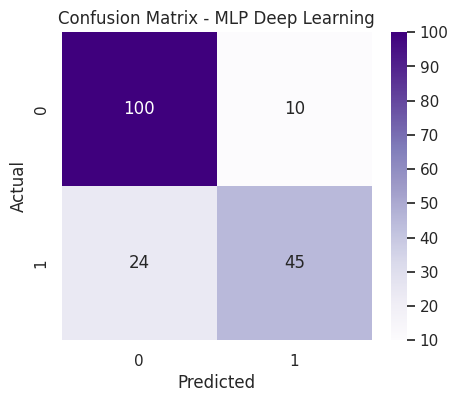

In [133]:
cm_mlp = confusion_matrix(y_val, y_pred_mlp)

plt.figure(figsize=(5,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - MLP Deep Learning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 41 — Tambahkan MLP ke tabel hasil

In [134]:
results.append(result_mlp)

results_df = pd.DataFrame(results)
results_df.sort_values(by='F1-score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,Training Time
0,Logistic Regression,0.843575,0.797101,0.797101,0.797101,0.024964
1,Random Forest,0.798883,0.720000,0.782609,0.750000,0.423111
2,MLP Deep Learning,0.810056,0.818182,0.652174,0.725806,26.273836


# Step 42 — Tambahkan jumlah parameter MLP

In [135]:
mlp_params = mlp.count_params()
print("Jumlah parameter MLP:", mlp_params)

Jumlah parameter MLP: 4417


Lalu tambahkan ke tabel:

In [136]:
results_df.loc[results_df['Model'] == 'MLP Deep Learning', 'Parameters'] = mlp_params
results_df.loc[results_df['Model'] == 'Logistic Regression', 'Parameters'] = 'N/A'
results_df.loc[results_df['Model'] == 'Random Forest', 'Parameters'] = 'N/A'

results_df

/tmp/ipykernel_12747/334458898.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N/A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_df.loc[results_df['Model'] == 'Logistic Regression', 'Parameters'] = 'N/A'


,Model,Accuracy,Precision,Recall,F1-score,Training Time,Parameters
0,Logistic Regression,0.843575,0.797101,0.797101,0.797101,0.024964,N/A
1,Random Forest,0.798883,0.720000,0.782609,0.750000,0.423111,N/A
2,MLP Deep Learning,0.810056,0.818182,0.652174,0.725806,26.273836,4417.0


# Error Analysis
# Step 45 — Buat dataframe validation untuk analisis error

In [137]:
val_analysis = train_df.loc[X_val.index].copy()

val_analysis['Actual'] = y_val.values
val_analysis['Pred_LogReg'] = y_pred_logreg
val_analysis['Pred_RF'] = y_pred_rf
val_analysis['Pred_MLP'] = y_pred_mlp

val_analysis.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Actual,Pred_LogReg,Pred_RF,Pred_MLP
565,566,0,3,"Davies, Mr. Alfred J",male,24.0,2,0,A/4 48871,24.1500,NaN,S,0,0,0,0
160,161,0,3,"Cribb, Mr. John Hatfield",male,44.0,0,1,371362,16.1000,NaN,S,0,0,0,0
553,554,1,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C,1,0,0,0
860,861,0,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,NaN,S,0,0,0,0
241,242,1,3,"Murphy, Miss. Katherine ""Kate""",female,NaN,1,0,367230,15.5000,NaN,Q,1,1,1,1


# Step 46 — Lihat contoh kesalahan Logistic Regression

In [138]:
errors_logreg = val_analysis[val_analysis['Actual'] != val_analysis['Pred_LogReg']]

errors_logreg[[
    'PassengerId', 'Name', 'Sex', 'Age', 'Pclass', 'SibSp', 'Parch',
    'Fare', 'Embarked', 'Actual', 'Pred_LogReg'
]].head(10)

,PassengerId,Name,Sex,Age,Pclass,SibSp,Parch,Fare,Embarked,Actual,Pred_LogReg
553,554,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,3,0,0,7.2250,C,1,0
536,537,"Butt, Major. Archibald Willingham",male,45.0,1,0,0,26.5500,S,0,1
712,713,"Taylor, Mr. Elmer Zebley",male,48.0,1,1,0,52.0000,S,1,0
455,456,"Jalsevac, Mr. Ivan",male,29.0,3,0,0,7.8958,C,1,0
297,298,"Allison, Miss. Helen Loraine",female,2.0,1,1,2,151.5500,S,0,1
40,41,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.0,3,1,0,9.4750,S,0,1
564,565,"Meanwell, Miss. (Marion Ogden)",female,NaN,3,0,0,8.0500,S,0,1
502,503,"O'Sullivan, Miss. Bridget Mary",female,NaN,3,0,0,7.6292,Q,0,1
17,18,"Williams, Mr. Charles Eugene",male,NaN,2,0,0,13.0000,S,1,0
701,702,"Silverthorne, Mr. Spencer Victor",male,35.0,1,0,0,26.2875,S,1,0


# Step 47 — Lihat contoh kesalahan Random Forest

In [139]:
errors_rf = val_analysis[val_analysis['Actual'] != val_analysis['Pred_RF']]

errors_rf[[
    'PassengerId', 'Name', 'Sex', 'Age', 'Pclass', 'SibSp', 'Parch',
    'Fare', 'Embarked', 'Actual', 'Pred_RF'
]].head(10)

,PassengerId,Name,Sex,Age,Pclass,SibSp,Parch,Fare,Embarked,Actual,Pred_RF
553,554,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,3,0,0,7.2250,C,1,0
536,537,"Butt, Major. Archibald Willingham",male,45.0,1,0,0,26.5500,S,0,1
698,699,"Thayer, Mr. John Borland",male,49.0,1,1,1,110.8833,C,0,1
712,713,"Taylor, Mr. Elmer Zebley",male,48.0,1,1,0,52.0000,S,1,0
455,456,"Jalsevac, Mr. Ivan",male,29.0,3,0,0,7.8958,C,1,0
745,746,"Crosby, Capt. Edward Gifford",male,70.0,1,1,1,71.0000,S,0,1
297,298,"Allison, Miss. Helen Loraine",female,2.0,1,1,2,151.5500,S,0,1
40,41,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.0,3,1,0,9.4750,S,0,1
564,565,"Meanwell, Miss. (Marion Ogden)",female,NaN,3,0,0,8.0500,S,0,1
502,503,"O'Sullivan, Miss. Bridget Mary",female,NaN,3,0,0,7.6292,Q,0,1


# Step 48 — Lihat contoh kesalahan MLP

In [140]:
errors_mlp = val_analysis[val_analysis['Actual'] != val_analysis['Pred_MLP']]

errors_mlp[[
    'PassengerId', 'Name', 'Sex', 'Age', 'Pclass', 'SibSp', 'Parch',
    'Fare', 'Embarked', 'Actual', 'Pred_MLP'
]].head(10)

,PassengerId,Name,Sex,Age,Pclass,SibSp,Parch,Fare,Embarked,Actual,Pred_MLP
553,554,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,3,0,0,7.2250,C,1,0
559,560,"de Messemaeker, Mrs. Guillaume Joseph (Emma)",female,36.0,3,1,0,17.4000,S,1,0
536,537,"Butt, Major. Archibald Willingham",male,45.0,1,0,0,26.5500,S,0,1
216,217,"Honkanen, Miss. Eliina",female,27.0,3,0,0,7.9250,S,1,0
712,713,"Taylor, Mr. Elmer Zebley",male,48.0,1,1,0,52.0000,S,1,0
455,456,"Jalsevac, Mr. Ivan",male,29.0,3,0,0,7.8958,C,1,0
869,870,"Johnson, Master. Harold Theodor",male,4.0,3,1,1,11.1333,S,1,0
417,418,"Silven, Miss. Lyyli Karoliina",female,18.0,2,0,2,13.0000,S,1,0
297,298,"Allison, Miss. Helen Loraine",female,2.0,1,1,2,151.5500,S,0,1
502,503,"O'Sullivan, Miss. Bridget Mary",female,NaN,3,0,0,7.6292,Q,0,1


# Step 49 — Hitung jumlah error tiap model

In [141]:
print("Jumlah error Logistic Regression:", len(errors_logreg))
print("Jumlah error Random Forest:", len(errors_rf))
print("Jumlah error MLP:", len(errors_mlp))

Jumlah error Logistic Regression: 28
Jumlah error Random Forest: 36
Jumlah error MLP: 34


# Step 50 — Bandingkan error antar model

In [142]:
common_errors = val_analysis[
    (val_analysis['Actual'] != val_analysis['Pred_LogReg']) &
    (val_analysis['Actual'] != val_analysis['Pred_RF']) &
    (val_analysis['Actual'] != val_analysis['Pred_MLP'])
]

common_errors[[
    'PassengerId', 'Name', 'Sex', 'Age', 'Pclass', 'SibSp', 'Parch',
    'Fare', 'Embarked', 'Actual', 'Pred_LogReg', 'Pred_RF', 'Pred_MLP'
]].head(10)

,PassengerId,Name,Sex,Age,Pclass,SibSp,Parch,Fare,Embarked,Actual,Pred_LogReg,Pred_RF,Pred_MLP
553,554,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,3,0,0,7.2250,C,1,0,0,0
536,537,"Butt, Major. Archibald Willingham",male,45.0,1,0,0,26.5500,S,0,1,1,1
712,713,"Taylor, Mr. Elmer Zebley",male,48.0,1,1,0,52.0000,S,1,0,0,0
455,456,"Jalsevac, Mr. Ivan",male,29.0,3,0,0,7.8958,C,1,0,0,0
297,298,"Allison, Miss. Helen Loraine",female,2.0,1,1,2,151.5500,S,0,1,1,1
502,503,"O'Sullivan, Miss. Bridget Mary",female,NaN,3,0,0,7.6292,Q,0,1,1,1
17,18,"Williams, Mr. Charles Eugene",male,NaN,2,0,0,13.0000,S,1,0,0,0
447,448,"Seward, Mr. Frederic Kimber",male,34.0,1,0,0,26.5500,S,1,0,0,0
578,579,"Caram, Mrs. Joseph (Maria Elias)",female,NaN,3,1,0,14.4583,C,0,1,1,1
501,502,"Canavan, Miss. Mary",female,21.0,3,0,0,7.7500,Q,0,1,1,1


# Step 51 — Ambil 3 contoh error untuk laporan

In [143]:
error_examples = common_errors[[
    'PassengerId', 'Name', 'Sex', 'Age', 'Pclass', 'SibSp', 'Parch',
    'Fare', 'Embarked', 'Actual', 'Pred_LogReg', 'Pred_RF', 'Pred_MLP'
]].head(3)

error_examples

,PassengerId,Name,Sex,Age,Pclass,SibSp,Parch,Fare,Embarked,Actual,Pred_LogReg,Pred_RF,Pred_MLP
553,554,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,3,0,0,7.225,C,1,0,0,0
536,537,"Butt, Major. Archibald Willingham",male,45.0,1,0,0,26.550,S,0,1,1,1
712,713,"Taylor, Mr. Elmer Zebley",male,48.0,1,1,0,52.000,S,1,0,0,0


# Step 52 — Template analisis error untuk laporan

Berdasarkan analisis error, sebagian kesalahan prediksi terjadi pada penumpang dengan karakteristik yang tidak sepenuhnya mengikuti pola umum survival Titanic. Misalnya, model cenderung memprediksi perempuan atau penumpang kelas tinggi sebagai selamat, namun terdapat beberapa kasus di mana penumpang dengan karakteristik tersebut ternyata tidak selamat. Sebaliknya, beberapa penumpang laki-laki atau penumpang kelas rendah yang secara statistik memiliki peluang selamat lebih rendah ternyata berhasil selamat.

Kesalahan ini menunjukkan bahwa fitur yang tersedia pada dataset tidak sepenuhnya merepresentasikan faktor-faktor penting saat kejadian, seperti lokasi pasti penumpang di kapal, akses ke sekoci, kondisi fisik, keputusan kru, atau faktor keberuntungan. Oleh karena itu, meskipun model mampu menangkap pola umum, masih terdapat ketidakpastian yang sulit diprediksi hanya dari fitur demografis dan tiket.

# Step 53 — Pilih model terbaik

In [144]:
results_df.sort_values(by='F1-score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,Training Time,Parameters
0,Logistic Regression,0.843575,0.797101,0.797101,0.797101,0.024964,N/A
1,Random Forest,0.798883,0.720000,0.782609,0.750000,0.423111,N/A
2,MLP Deep Learning,0.810056,0.818182,0.652174,0.725806,26.273836,4417.0


# Step 54 — Prediksi test set untuk submission Kaggle

In [145]:
test_predictions = logreg.predict(X_test_scaled)

# Step 55 — Buat file submission

In [146]:
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [147]:
submission.shape

(418, 2)

# Step 56 — Simpan submission CSV

In [148]:
submission.to_csv('submission_titanic.csv', index=False)

In [149]:
from google.colab import files

files.download('submission_titanic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>